In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

Error funct $E_i(t)$:

$e(t) = y_i(t) - x_i(t)$

where $x_i(t)$ is the real value for the $i$th component in phase space and $y_i(t)$ is the target value

To construct the controller, we need the three following components:

Proportional component:
$P_i(t) = k_i e(x_i, t)$

Integral component:
$I_i(t) = l_i \int_{t_i}^{t}E(t')dt'$

Derivative component:
$D_i(t) = m_i \frac{d E_i(t)}{dt}$

Where $k_i$, $l_i$, $t_i$ (integral window length), and $m_i(t)$ are parameters we can use to tune our controller. 

In [ ]:
class PIDController:

    err_buffer: deque
    k: float
    l: float
    m: float

    def __init__(self, k, l, m, int_len=10):
        self.k = k
        self.l = l
        self.m = m
        self.err_buffer = deque(maxlen=int_len)

    def update(self, target, measurement, dt):
        err = target - measurement
        self.err_buffer.append(err)
        int_err = sum(self.err_buffer) * dt
        der_err = (self.err_buffer[-1] - self.err_buffer[-2]) / dt if len(self.err_buffer) > 1 else 0
        return self.k * err + self.l * int_err + self.m * der_err
        

In [ ]:
class System:

    state: list[float]
    dimensions: int
    funcs: list
    derivs: list
    integration_method: str
    timestep: float

    def __init__(self, funcs: list = [lambda x: x/2], derivs: list = [lambda x: 1/2], initial_state: list[float] = [0], timestep = 1, integration_method = 'euler'):
        self.dimensions = len(initial_state)
        self.state = initial_state
        self.funcs = funcs
        self.derivs = derivs
        self.integration_method = integration_method
        self.timestep = float(timestep)

    def update(self, control_input, dt):
        if self.integration_method == 'euler':
            self.state = self.euler(self.state)
        elif self.integration_method == 'rk4':
            self.state = self.rk4(self.state)
        return self.state

    def euler(self, x):
        return [f(x[i]) * self.timestep for i, f in enumerate(self.funcs)]
    
    def rk4(self, x):
        k1 = [f(x[i]) for i, f in enumerate(self.derivs)]
        k2 = [f(x[i] + self.timestep * k1[i] / 2) for i, f in enumerate(self.derivs)]
        k3 = [f(x[i] + self.timestep * k2[i] / 2) for i, f in enumerate(self.derivs)]
        k4 = [f(x[i] + self.timestep * k3[i]) for i, f in enumerate(self.derivs)]
        return [x[i] + (self.timestep / 6) * (k1[i] + 2*k2[i] + 2*k3[i] + k4[i]) for i in range(self.dimensions)]

In [ ]:
class PIDGridSearch:

    mses: dict
    targets: dict
    positions: dict
    t_stamps: np.ndarray

    def __init__(self, k_range, l_range, m_range, int_len_range):
        self.k_range = k_range
        self.l_range = l_range
        self.m_range = m_range
        self.int_len_range = int_len_range
        self.targets = {}
        self.positions = {}
        self.mses = {}

    def search(self, t_stamps, target, pi):
        self.best_params = None
        self.t_stamps = t_stamps
        best_mse = float('inf')
        for k in self.k_range:
            for l in self.l_range:
                for m in self.m_range:
                    for int_len in self.int_len_range:
                        pid = PIDController(k, l, m, int_len)
                        position = []
                        measurement = pi
                        for t in range(len(t_stamps)):
                            dt = t_stamps[t] - t_stamps[t-1] if t > 0 else 1
                            control_sig = pid.update(target[t], measurement, dt) 
                            measurement = control_sig
                            position.append(measurement)
                        mse = np.mean((target - position) ** 2)
                        self.mses[(k, l, m, int_len)] = mse
                        self.targets[(k, l, m, int_len)] = target
                        self.positions[(k, l, m, int_len)] = position
                        if mse < best_mse:
                            best_mse = mse
                            self.best_params = (k, l, m, int_len)
        return self.best_params
    
    def gen_plot(self, k, l, m, int_len):
        figure, ax = plt.subplots()
        ax.plot(self.t_stamps, self.positions[(k, l, m, int_len)], label='Position')
        ax.plot(self.t_stamps, self.targets[(k, l, m, int_len)], label='Target')
        ax.set_title(f'PID Control (k={k:.2f}, l={l:.2f}, m={m:.2f}, Interval length={int_len})')
        ax.set_xlabel('Time')
        ax.set_ylabel('Position')
        plt.legend()
        plt.show()
    
    def gen_plot_tup(self, best_params):
        k, l, m, int_len = best_params
        self.gen_plot(k, l, m, int_len)

    def get_mse(self, k, l, m, int_len):
        return self.mses[(k, l, m, int_len)]
    
    def get_mse_tup(self, best_params):
        k, l, m, int_len = best_params
        return self.mses[(k, l, m, int_len)]
    

Let's search for the best parameters for $k, l, m, t$ over a grid given some piecewise linear target.

In [17]:
k_range = np.linspace(0, 1, 11)
l_range = np.linspace(0, 1, 11)
m_range = np.linspace(0, 0.4, 5)
int_len_range = [10, 100]
t = np.linspace(0, 1000, 1000)

target = np.piecewise(t, [t < 100, (t >= 100) & (t < 500), (t >= 500) & (t < 510), (t >=510) & (t < 600), t > 600], [2, 1, 0, 10, 5, 0])

grid_search = PIDGridSearch(k_range, l_range, m_range, int_len_range)
best_params = grid_search.search(t_stamps=t, target=target, pi=0)

print(f'Best PID parameters: k={best_params[0]:.2f}, l={best_params[1]:.2f}, m={best_params[2]:.2f}, Interval length={best_params[3]}')
print('k_range:', k_range)
print('l_range:', l_range)
print('m_range:', m_range)
print('int_len_range:', int_len_range)

Best PID parameters: k=0.90, l=0.00, m=0.00, Interval length=100
k_range: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
l_range: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
m_range: [0.  0.1 0.2 0.3 0.4]
int_len_range: [10, 100]


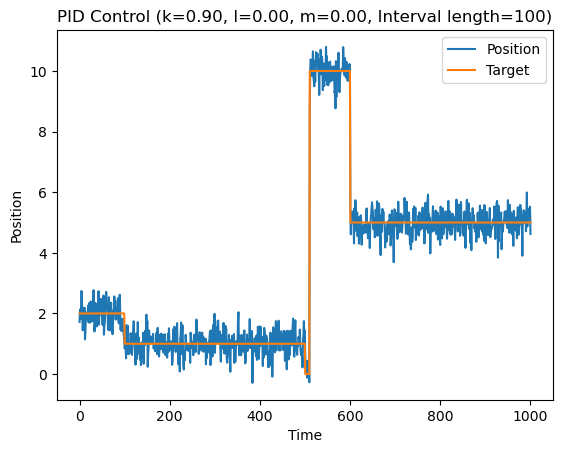

np.float64(0.145954803120189)

In [18]:
grid_search.gen_plot_tup(best_params)
grid_search.get_mse_tup(best_params)

Best case with white noise and flat linear piecewise function is the proportional controller. This makes sense, we completely remove the noise term and centre the probability of being on the target path each step with proportional term only. Realistically though, we would not be able to make our system variables jump so suddenly just because we will them to. This is where the *process* comes into play. Given a value returned from the controller of our control variable, we must find how this translates to the state variables of our system. The process block controls this. Note that in physical applications this is not generally a constant, and will likely be a function of many complex variables.